In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time



def master_trial_pulse_prediction(dt, period = np.random.uniform(), n_events = 5, hint = 'nohint', mode = 0, delay = 0, showplots = 0, tempo_change = 0)
    
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    plt.plot(fin)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


random_pulses(dt=0.001,showplots=1)


SyntaxError: invalid syntax (3715880375.py, line 7)

Epoch 1/5


StagingError: in user code:

    File "C:\Users\Manav\AppData\Roaming\Python\Python38\site-packages\keras\src\engine\training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\Manav\AppData\Roaming\Python\Python38\site-packages\tension\models.py", line 352, in train_step  *
        self.update_output_kernel(h_task,
    File "C:\Users\Manav\AppData\Roaming\Python\Python38\site-packages\tension\base.py", line 488, in update_output_kernel  *
        self.optimizer.apply_gradients(zip([dwO], [trainable_vars_output_kernel]))
    File "C:\Users\Manav\AppData\Roaming\Python\Python38\site-packages\keras\src\optimizers\optimizer.py", line 1230, in apply_gradients  **
        return super().apply_gradients(grads_and_vars, name=name)
    File "C:\Users\Manav\AppData\Roaming\Python\Python38\site-packages\keras\src\optimizers\optimizer.py", line 652, in apply_gradients
        iteration = self._internal_apply_gradients(grads_and_vars)
    File "C:\

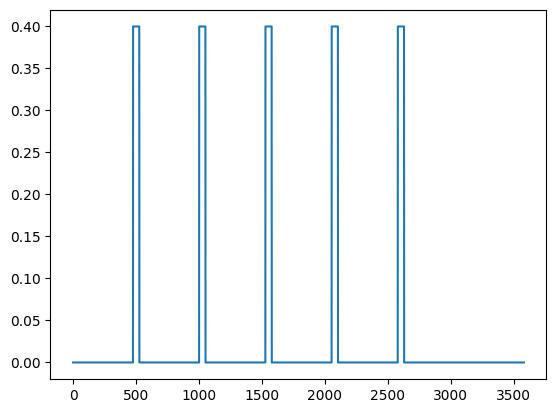

In [16]:
from tension.models import FullFORCEModel, NoFeedbackESN

no_fb_esn_layer = NoFeedbackESN(dtdivtau=0.1,units=1000,output_size=1,activation = 'tanh')

ffmodel = FullFORCEModel(force_layer = no_fb_esn_layer, target_output_kernel_trainable = False, hint_dim=1)
ffmodel.compile(metrics=["mae"])

fin, fout, fhint = random_pulses(dt=0.001,showplots=0)
fout = fout.astype(np.float32)

history = ffmodel.fit(x= np.concatenate([fin, fhint], axis=1).astype(np.float32),
                     y = fout,
                     epochs = 5)
predictions = ffmodel.predict(input_tensor)

In [2]:
print(round(0.5))
print(round(1.5))
print(round(2.5))

0
2
2
